# ADA Project Outline
1. load HKO provided data and preprocess
2. model training and evaluation
3. generate predictions

## 1. load HKO provided data and preprocess
All datasets are downloaded from https://data.gov.hk/sc-datasets/category/climate-and-weather  
All data are collected at the Hong Kong Observatory  
### 1.1 load raw data
The raw csv contains over a century of data. In this project, we only take the most recent 15 years, from 2011 to 2025  
Output the consolidated raw data as dataset_raw.csv

In [18]:
# Reload new CSV files, clean completeness, and merge into one dataset
import pandas as pd

# Required column order in the final table
file_to_feature = [
    ("t_max.csv", "T_max"),
    ("t_min.csv", "T_min"),
    ("rain.csv", "rain_mm"),
    ("RH.csv", "RH_mean"),
    ("cloud.csv", "cloud"),
    ("MSLP.csv", "MSLP"),
]

def load_one_hko_file(file_path, feature_name):
    # HKO files contain 3 metadata lines before the actual data rows
    df = pd.read_csv(
        file_path,
        skiprows=3,
        header=None,
        names=["Year", "Month", "Day", "Value", "Completeness"],
        encoding="utf-8-sig",
    )

    # Parse date fields safely
    df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
    df["Month"] = pd.to_numeric(df["Month"], errors="coerce")
    df["Day"] = pd.to_numeric(df["Day"], errors="coerce")
    df = df.dropna(subset=["Year", "Month", "Day"]).copy()

    # Keep only 2011-2025
    df["Year"] = df["Year"].astype(int)
    df["Month"] = df["Month"].astype(int)
    df["Day"] = df["Day"].astype(int)
    df = df[(df["Year"] >= 2011) & (df["Year"] <= 2025)].copy()

    # Mark non-C completeness rows as missing
    completeness = df["Completeness"].astype(str).str.strip()
    df.loc[completeness != "C", "Value"] = pd.NA

    # Convert value to numeric where possible
    df["Value"] = pd.to_numeric(df["Value"], errors="coerce")

    # Drop completeness column and prepare one feature column
    df = df.drop(columns=["Completeness"])
    df["date"] = pd.to_datetime(df[["Year", "Month", "Day"]], errors="coerce")
    df = df.dropna(subset=["date"]).copy()
    df = df[["date", "Value"]].rename(columns={"Value": feature_name})

    return df

merged = None
for file_name, feature_name in file_to_feature:
    one_df = load_one_hko_file(file_name, feature_name)
    if merged is None:
        merged = one_df
    else:
        merged = pd.merge(merged, one_df, on="date", how="outer")

final_columns = ["date", "T_max", "T_min", "rain_mm", "RH_mean", "cloud", "MSLP"]
dataset_raw = merged[final_columns].copy()

# Enforce date validity again at final stage, then remove invalid date rows
dataset_raw["date"] = pd.to_datetime(dataset_raw["date"], errors="coerce")
invalid_date_count = dataset_raw["date"].isna().sum()
dataset_raw = dataset_raw.dropna(subset=["date"]).copy()
dataset_raw = dataset_raw.sort_values("date").reset_index(drop=True)

# Export date as text (YYYY-MM-DD) to avoid Excel showing ####### on narrow columns
dataset_raw["date"] = dataset_raw["date"].dt.strftime("%Y-%m-%d")

# Export for inspection in Excel
dataset_raw.to_csv("dataset_raw.csv", index=False, encoding="utf-8-sig")

print("Saved: dataset_raw.csv")
print(f"Removed rows with invalid/unknown date: {invalid_date_count}")
print(dataset_raw.head())
print(dataset_raw.shape)

Saved: dataset_raw.csv
Removed rows with invalid/unknown date: 0
         date  T_max  T_min  rain_mm  RH_mean  cloud    MSLP
0  2011-01-01   17.2   12.7      0.0     57.0   14.0  1019.1
1  2011-01-02   16.3   14.1      0.0     65.0   83.0  1019.8
2  2011-01-03   15.5   12.6      NaN     72.0   91.0  1019.6
3  2011-01-04   14.6   12.1      1.2     81.0   95.0  1020.4
4  2011-01-05   17.9   13.9      0.0     77.0   91.0  1018.6
(5479, 7)


### 1.2 preprocess the raw data

#### 1.2.1 handle missing data and outliers
Missing data handling:  
- Continuous variables missing (T_max, T_min, RH_mean, MSLP):  
short missingvalues (< 3 days) are interpolated, long missing values (>= 3 days) result in row deletion  

- Non-continuous variable missing (rain_mm): all missing values are directly deleted  

Outlier handling:  
- Extreme but plausible values (e.g. heavy rain in typhoon): retained
- Other outliers in continuous variables: treated as missing values based on above rules

In [19]:
# Preprocess dataset_raw: handle missing values and outliers
import pandas as pd
import numpy as np

# Reload the raw dataset
dataset_raw = pd.read_csv('dataset_raw.csv')
dataset_raw['date'] = pd.to_datetime(dataset_raw['date'])
dataset_raw = dataset_raw.sort_values('date').reset_index(drop=True)

# Define continuous (imputable) and non-continuous (rain) variables
continuous_vars = ['T_max', 'T_min', 'RH_mean', 'MSLP']
rain_var = 'rain_mm'

# Step 1: Handle rain_mm (non-continuous) - directly drop all missing values
before_rain_drop = len(dataset_raw)
dataset_raw = dataset_raw.dropna(subset=[rain_var])
after_rain_drop = len(dataset_raw)
print(f'Dropped {before_rain_drop - after_rain_drop} rows due to missing rain_mm')

# Step 2: Handle continuous variables
# First, identify consecutive missing value groups and their lengths
for col in continuous_vars:
    missing_mask = dataset_raw[col].isna()
    # Find consecutive nan groups
    missing_groups = (~missing_mask).cumsum()[missing_mask]
    missing_lengths = missing_groups.groupby(missing_groups).size()
    
    # Mark rows with long missing stretches (>= 3 days) for deletion
    long_missing_groups = missing_lengths[missing_lengths >= 3].index.tolist()
    
    # Only drop rows if there are long missing groups
    if long_missing_groups:
        rows_to_drop = missing_mask.index[missing_groups.isin(long_missing_groups)].tolist()
        print(f'Dropping {len(rows_to_drop)} rows from {col} due to >= 3 consecutive missing values')
        dataset_raw.loc[rows_to_drop, col] = np.nan  # Mark before deletion

# Drop entire rows that have NaN in any continuous variable (represents long missing stretches)
before_drop = len(dataset_raw)
dataset_raw = dataset_raw.dropna(subset=continuous_vars)
after_drop = len(dataset_raw)
print(f'Total rows dropped due to long missing stretches in continuous variables: {before_drop - after_drop}')

# Step 3: Handle remaining short missing values in continuous variables (< 3 days)
# These will be interpolated
for col in continuous_vars:
    missing_count = dataset_raw[col].isna().sum()
    if missing_count > 0:
        dataset_raw[col] = dataset_raw[col].interpolate(method='linear', limit_direction='both')
        print(f'Interpolated {missing_count} missing values in {col}')


Dropped 1034 rows due to missing rain_mm
Total rows dropped due to long missing stretches in continuous variables: 0


#### 1.2.2 generate new derived features
- DTR =  T_max - T_min (diurnal temperature range)
- rain_freq = rainfall frequency in the previous seven days
- MSLP_delta = current day's MSLP - previous day's MSLP  

In [20]:
# Generate new derived features from preprocessed data
import pandas as pd
import numpy as np

# Add derived features to dataset_raw

# 1. Daily temperature range (DTR) = T_max - T_min
dataset_raw['DTR'] = dataset_raw['T_max'] - dataset_raw['T_min']

# 2. Past 7-day rain frequency = count of rainy days (rain_mm > 0) in past 7 days / 7
dataset_raw['rain_binary'] = (dataset_raw['rain_mm'] > 0).astype(int)
dataset_raw['rain_freq'] = dataset_raw['rain_binary'].rolling(window=7, min_periods=1).sum() / 7

# 3. MSLP change = current day - previous day
dataset_raw['MSLP_delta'] = dataset_raw['MSLP'].diff()

# Remove temporary column
dataset_raw = dataset_raw.drop(columns=['rain_binary'])

# Display summary
print('Generated derived features:')
print('- DTR (Daily Temperature Range) = T_max - T_min')
print('- rain_freq = 7-day rainfall frequency (rainy days / 7)')
print('- MSLP_delta = current MSLP - previous MSLP')
print(f'\nNew dataset columns: {list(dataset_raw.columns)}')
print(f'Dataset shape: {dataset_raw.shape}')
print('\nFirst 10 rows:')
print(dataset_raw.head(10))


Generated derived features:
- DTR (Daily Temperature Range) = T_max - T_min
- rain_freq = 7-day rainfall frequency (rainy days / 7)
- MSLP_delta = current MSLP - previous MSLP

New dataset columns: ['date', 'T_max', 'T_min', 'rain_mm', 'RH_mean', 'cloud', 'MSLP', 'DTR', 'rain_freq', 'MSLP_delta']
Dataset shape: (4445, 10)

First 10 rows:
         date  T_max  T_min  rain_mm  RH_mean  cloud    MSLP  DTR  rain_freq  \
0  2011-01-01   17.2   12.7      0.0     57.0   14.0  1019.1  4.5   0.000000   
1  2011-01-02   16.3   14.1      0.0     65.0   83.0  1019.8  2.2   0.000000   
3  2011-01-04   14.6   12.1      1.2     81.0   95.0  1020.4  2.5   0.142857   
4  2011-01-05   17.9   13.9      0.0     77.0   91.0  1018.6  4.0   0.142857   
6  2011-01-07   13.6    9.5      0.0     63.0   70.0  1024.2  4.1   0.142857   
7  2011-01-08   15.6    9.5      0.0     65.0   36.0  1021.3  6.1   0.142857   
8  2011-01-09   18.0   12.4      0.0     56.0   25.0  1020.2  5.6   0.142857   
9  2011-01-10   15.9

#### 1.2.3 descriptive statistics and visualization

DESCRIPTIVE STATISTICS
             count         mean        std    min          25%          50%  \
T_max       4445.0    26.779573   5.419633    7.1    22.500000    27.900000   
T_min       4445.0    22.113566   5.217602    3.1    18.000000    23.400000   
rain_mm     4445.0     7.982092  23.694554    0.0     0.000000     0.000000   
RH_mean     4445.0    77.434871  10.980266   28.0    72.000000    79.000000   
cloud       4445.0    67.849044  23.971714    0.0    53.000000    78.000000   
MSLP        4445.0  1012.566277   6.571689  988.5  1007.700000  1012.300000   
DTR         4445.0     4.666007   1.615894    0.6     3.500000     4.700000   
rain_freq   4445.0     0.494488   0.322476    0.0     0.285714     0.428571   
MSLP_delta  4444.0    -0.000968   2.251978  -18.3    -1.400000    -0.100000   

                    75%     max  
T_max         31.400000    36.6  
T_min         26.600000    30.0  
rain_mm        4.200000   425.0  
RH_mean       85.000000    99.0  
cloud         87

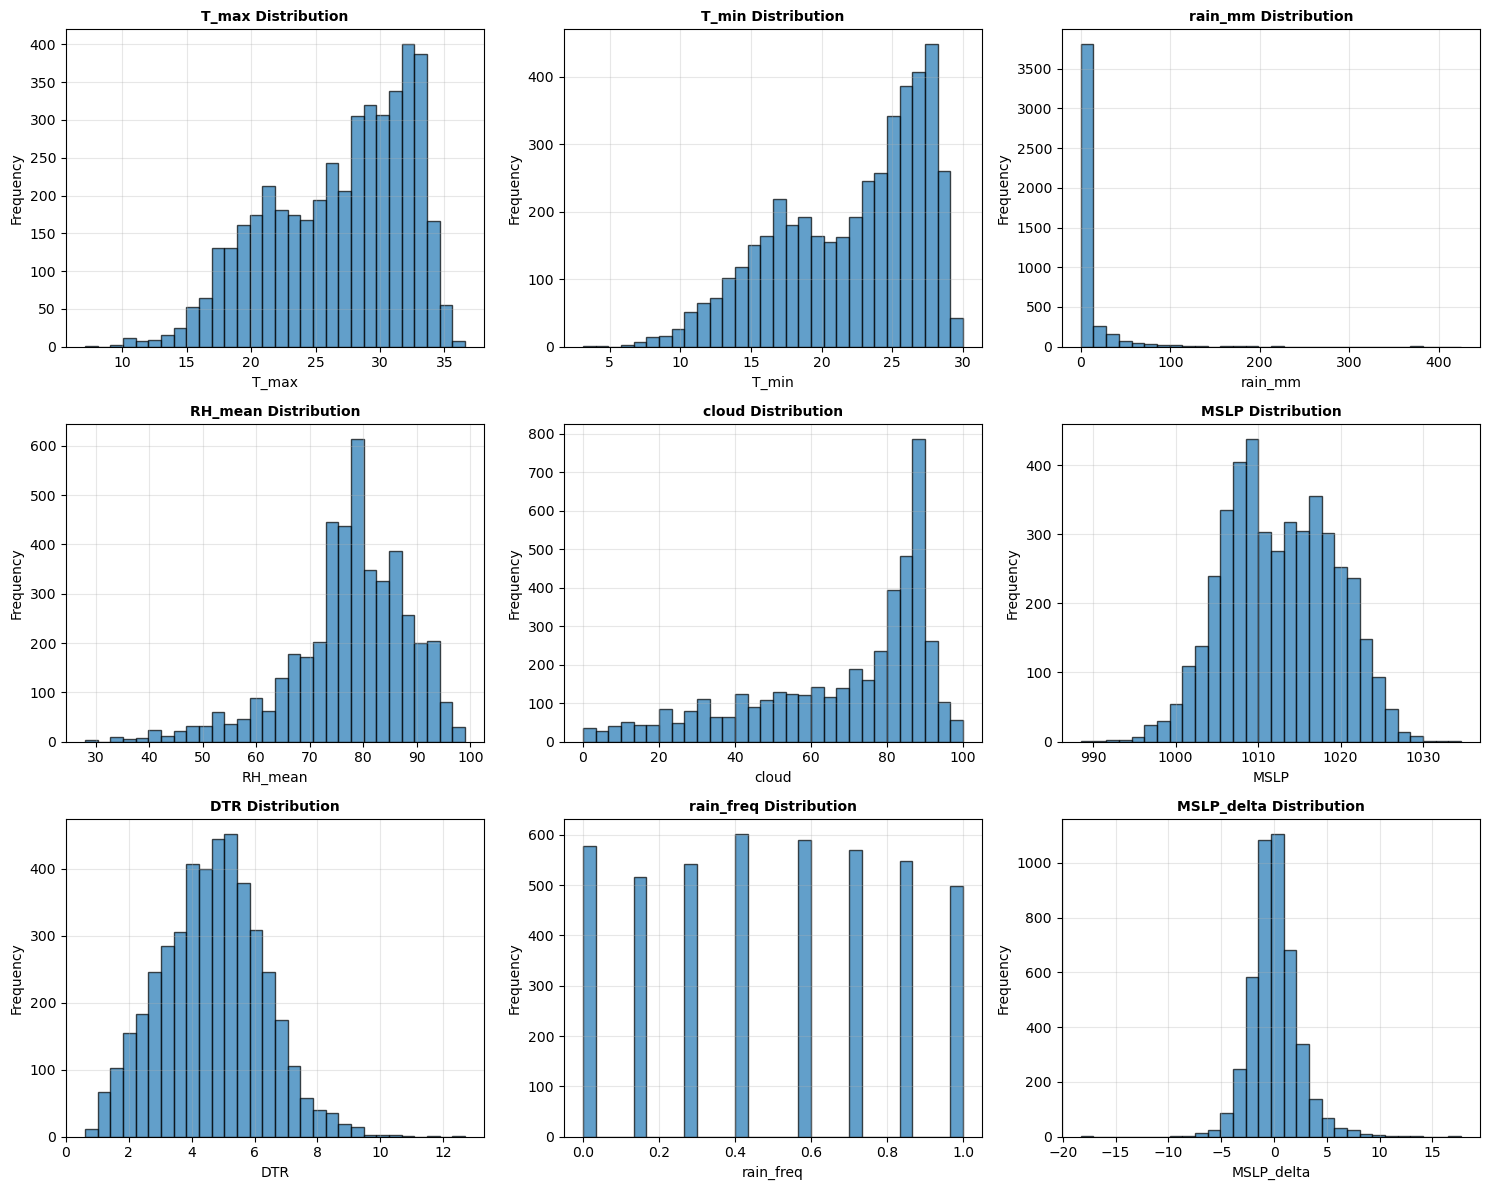

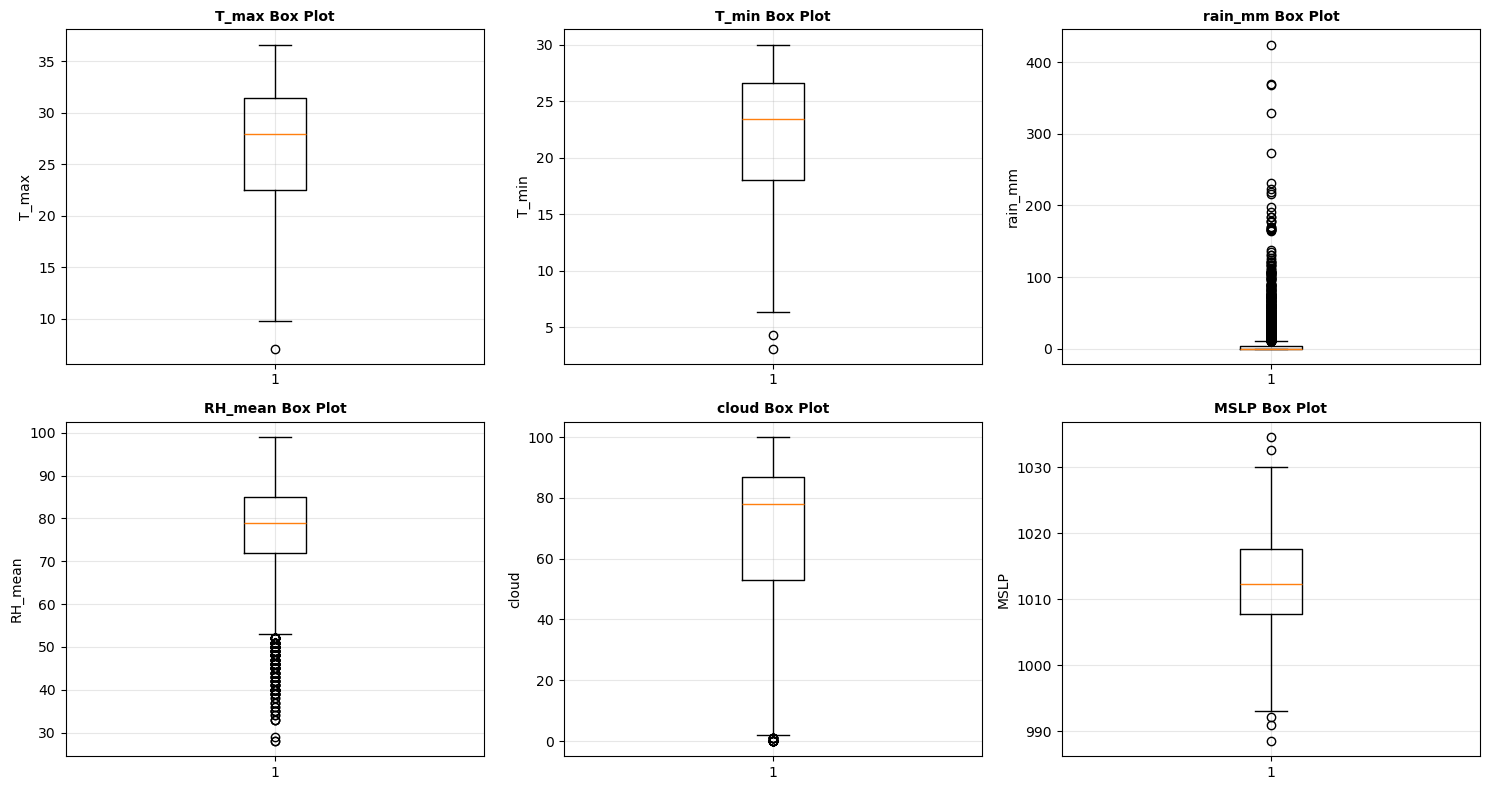

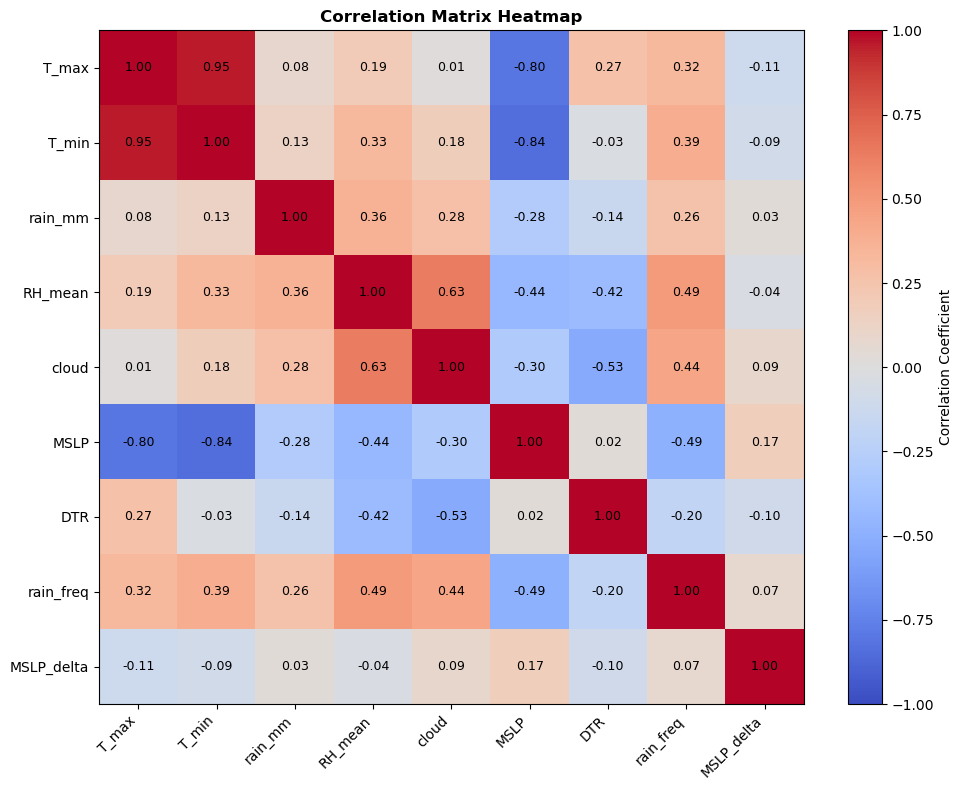


Descriptive statistics and visualization completed.


In [21]:

# Calculate descriptive statistics and visualize
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Select numeric columns (excluding date)
numeric_cols = dataset_raw.select_dtypes(include=[np.number]).columns.tolist()

# 1. Descriptive statistics table
print("=" * 80)
print("DESCRIPTIVE STATISTICS")
print("=" * 80)
desc_stats = dataset_raw[numeric_cols].describe().T
print(desc_stats)

# 2. Additional statistics (Skewness, Kurtosis, Missing values)
print("\n" + "=" * 80)
print("ADDITIONAL STATISTICS")
print("=" * 80)
additional_stats = pd.DataFrame({
    'Skewness': dataset_raw[numeric_cols].skew(),
    'Kurtosis': dataset_raw[numeric_cols].kurtosis(),
    'Missing_Count': dataset_raw[numeric_cols].isnull().sum(),
    'Missing_%': (dataset_raw[numeric_cols].isnull().sum() / len(dataset_raw) * 100).round(2)
})
print(additional_stats)

# 3. Correlation matrix
print("\n" + "=" * 80)
print("CORRELATION MATRIX")
print("=" * 80)
corr_matrix = dataset_raw[numeric_cols].corr()
print(corr_matrix)

# 4. Distribution histograms
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    if idx < len(axes):
        axes[idx].hist(dataset_raw[col].dropna(), bins=30, alpha=0.7, edgecolor='black')
        axes[idx].set_title(f'{col} Distribution', fontsize=10, fontweight='bold')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Frequency')
        axes[idx].grid(alpha=0.3)

for idx in range(len(numeric_cols), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

# 5. Box plots for outlier detection
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    if idx < len(axes):
        axes[idx].boxplot(dataset_raw[col].dropna())
        axes[idx].set_title(f'{col} Box Plot', fontsize=10, fontweight='bold')
        axes[idx].set_ylabel(col)
        axes[idx].grid(alpha=0.3)

for idx in range(len(numeric_cols), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

# 6. Correlation heatmap using matplotlib
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)

# Set ticks and labels
ax.set_xticks(np.arange(len(corr_matrix.columns)))
ax.set_yticks(np.arange(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right')
ax.set_yticklabels(corr_matrix.columns)

# Add correlation values as text
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        text = ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                      ha="center", va="center", color="black", fontsize=9)

ax.set_title('Correlation Matrix Heatmap', fontsize=12, fontweight='bold')
fig.colorbar(im, ax=ax, label='Correlation Coefficient')
plt.tight_layout()
plt.show()

print("\nDescriptive statistics and visualization completed.")


#### 1.2.4 scaling and export final datasets
Output two versions of the dataset: 
- one unscaled for ARIMA, named "dataset_for_arima.csv"
- the other normalized for logistic regression and LSTM, named "dataset_normalized_lstm.csv"

In [22]:

# Scaling and export final datasets
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Separate date and numeric columns
date_col = dataset_raw['date'].copy()
numeric_cols = dataset_raw.select_dtypes(include=[np.number]).columns.tolist()
numeric_data = dataset_raw[numeric_cols].copy()

# Step 1: Export unscaled version for ARIMA (with date column)
dataset_for_arima = pd.DataFrame({
    'date': date_col,
    **numeric_data
})
dataset_for_arima.to_csv('dataset_for_arima.csv', index=False, encoding='utf-8-sig')
print("Exported unscaled dataset for ARIMA: dataset_for_arima.csv")
print(f"Shape: {dataset_for_arima.shape}")
print(dataset_for_arima.head())

# Step 2: Scale numeric data using StandardScaler for LSTM and other models
scaler = StandardScaler()
scaled_numeric_data = scaler.fit_transform(numeric_data)
scaled_numeric_data = pd.DataFrame(scaled_numeric_data, columns=numeric_cols)

# Create scaled dataset with date column
dataset_normalized = pd.DataFrame({
    'date': date_col.reset_index(drop=True),
    **scaled_numeric_data
})

# Export scaled version for LSTM
dataset_normalized.to_csv('dataset_normalized_lstm.csv', index=False, encoding='utf-8-sig')
print("\n" + "=" * 80)
print("Exported scaled dataset for LSTM: dataset_normalized_lstm.csv")
print(f"Shape: {dataset_normalized.shape}")
print(dataset_normalized.head())

# Step 3: Display scaling statistics
print("\n" + "=" * 80)
print("SCALING STATISTICS (StandardScaler)")
print("=" * 80)
scaling_stats = pd.DataFrame({
    'Feature': numeric_cols,
    'Mean': scaler.mean_,
    'Std': scaler.scale_
})
print(scaling_stats)

print("\n" + "=" * 80)
print("Data preprocessing completed successfully!")
print("Output files:")
print("  - dataset_for_arima.csv (unscaled)")
print("  - dataset_normalized_lstm.csv (scaled with StandardScaler)")


Exported unscaled dataset for ARIMA: dataset_for_arima.csv
Shape: (4445, 10)
        date  T_max  T_min  rain_mm  RH_mean  cloud    MSLP  DTR  rain_freq  \
0 2011-01-01   17.2   12.7      0.0     57.0   14.0  1019.1  4.5   0.000000   
1 2011-01-02   16.3   14.1      0.0     65.0   83.0  1019.8  2.2   0.000000   
3 2011-01-04   14.6   12.1      1.2     81.0   95.0  1020.4  2.5   0.142857   
4 2011-01-05   17.9   13.9      0.0     77.0   91.0  1018.6  4.0   0.142857   
6 2011-01-07   13.6    9.5      0.0     63.0   70.0  1024.2  4.1   0.142857   

   MSLP_delta  
0         NaN  
1         0.7  
3         0.6  
4        -1.8  
6         5.6  

Exported scaled dataset for LSTM: dataset_normalized_lstm.csv
Shape: (4445, 10)
        date     T_max     T_min   rain_mm   RH_mean     cloud      MSLP  \
0 2011-01-01 -1.767767 -1.804397 -0.336912 -1.861264 -2.246610  0.994335   
1 2011-01-02 -1.933849 -1.536044 -0.336912 -1.132602  0.632106  1.100864   
2 2011-01-04 -2.247559 -1.919405 -0.286262 